 ## Regression and Evaluation – California Housing Dataset

In [59]:
# Import libraries required for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import dataset
from sklearn.datasets import fetch_california_housing

# Import preprocessing and splitting tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import pipeline and cross-validation tools
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [60]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Convert the features into a pandas DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Create the target variable
y = pd.Series(housing.target, name="MedHouseVal")
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [61]:
# Display the shape of the feature dataset
print("Feature shape:", X.shape)

# Display the shape of the target variable
print("Target shape:", y.shape)

# Display feature names
print("\nFeature names:")
print(X.columns.tolist())

Feature shape: (20640, 8)
Target shape: (20640,)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [62]:
# Combine features and target into one DataFrame for easy inspection
df = X.copy()
df["MedHouseVal"] = y

# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [64]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [65]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


The dataset was checked for missing values. The California Housing dataset
does not contain missing values, so no missing-value imputation is required.

Exploratory Data Analysis — EDA

1 Distribution of Target

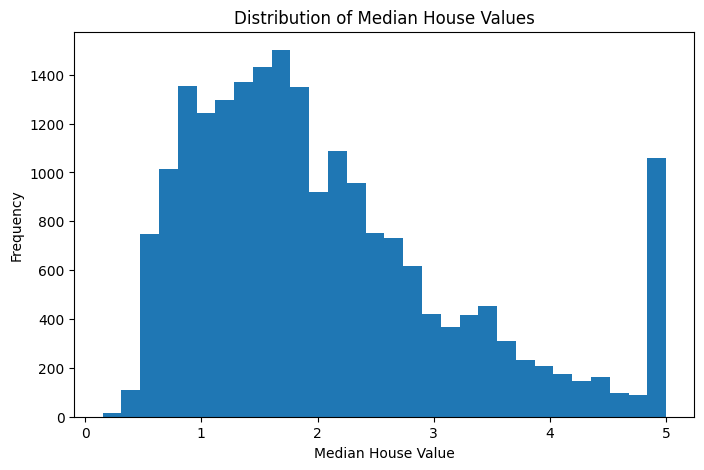

In [66]:
# Plot the distribution of median house values
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Values")
plt.show()

2 Feature Correlation

In [67]:
# Calculate correlations between numerical features and target
correlation = df.corr()["MedHouseVal"].sort_values(ascending=False)

# Display the correlations
print(correlation)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


3 Scatter Plot

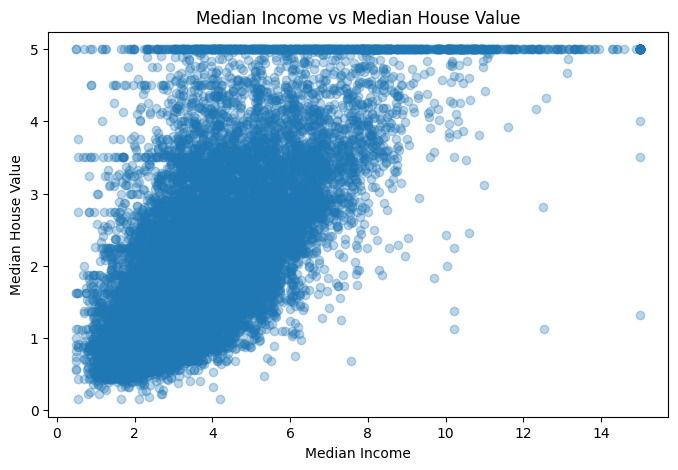

In [68]:
# Plot median income against median house value
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

Train-Test Split

In [69]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)


### Feature Scaling

StandardScaler is used to standardize the features. It transforms the
features so that they have approximately zero mean and unit variance.

Scaling is particularly useful for Linear Regression and SVR because
these algorithms can be affected by differences in feature scales.

### Linear Regression

Linear Regression models the relationship between the input features and
the target variable using a linear equation.

It is suitable as a baseline model because it is simple, fast and easy
to interpret.

In [70]:
# Create a Linear Regression pipeline with feature scaling
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train the Linear Regression model
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

### Decision Tree Regressor

A Decision Tree Regressor predicts values by splitting the data into
different branches based on feature values.

It is suitable for the California Housing dataset because it can model
non-linear relationships between housing features and house prices.

In [71]:
# Create a Decision Tree Regressor
tree_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
tree_predictions = tree_model.predict(X_test)

### Random Forest Regressor

Random Forest combines multiple decision trees and averages their
predictions.

It is suitable for this dataset because it can capture complex
non-linear relationships and is generally more robust than a single
decision tree.

In [72]:
# Create a Random Forest Regressor
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
forest_model.fit(X_train, y_train)

# Make predictions
forest_predictions = forest_model.predict(X_test)

### Gradient Boosting Regressor

Gradient Boosting builds multiple weak prediction models sequentially.
Each new model tries to reduce the errors made by previous models.

It is suitable because it can learn complex non-linear patterns in
housing data.

In [73]:
# Create a Gradient Boosting Regressor
gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
gradient_model.fit(X_train, y_train)

# Make predictions
gradient_predictions = gradient_model.predict(X_test)

### Support Vector Regressor

SVR tries to find a function that predicts the target values while
allowing a small amount of error.

SVR can model non-linear relationships using kernels. Standardization
is important for SVR because it is sensitive to feature scales.

In [ ]:
# Create an SVR pipeline with feature scaling
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

# Train the SVR model
svr_model.fit(X_train, y_train)

# Make predictions
svr_predictions = svr_model.predict(X_test)

Evaluate All Models

In [ ]:
# Store all models and their predictions in a dictionary
predictions = {
    "Linear Regression": linear_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions,
    "Gradient Boosting": gradient_predictions,
    "SVR": svr_predictions
}

# Create an empty list to store evaluation results
results = []

# Calculate evaluation metrics for every model
for model_name, prediction in predictions.items():

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, prediction)

    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_test, prediction)

    # Calculate R-squared score
    r2 = r2_score(y_test, prediction)

    # Store the results
    results.append([model_name, mse, mae, r2])

# Convert results into a DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "R2"]
)

# Display the results
results_df

### Evaluation Metrics

Mean Squared Error (MSE):
Lower values indicate better performance.

Mean Absolute Error (MAE):
Lower values indicate that the predictions are closer to the actual
values on average.

R-squared (R²):
Higher values indicate that the model explains more variation in the
target variable.

Therefore, a good regression model generally has low MSE and MAE and
a high R² score.

### Compare the Models

In [ ]:
# Sort models by R² score from highest to lowest
results_df.sort_values(
    by="R2",
    ascending=False
)

In [ ]:
# Find the model with the highest R² score
best_model = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

# Find the model with the lowest R² score
worst_model = results_df.loc[
    results_df["R2"].idxmin(),
    "Model"
]

# Display the results
print("Best model based on R²:", best_model)
print("Lowest-performing model based on R²:", worst_model)

Model Comparison

The models were compared using MSE, MAE and R².

The model with the highest R² and relatively lower MSE and MAE is considered
the strongest model based on the test-set evaluation.

The model with the lowest R² and higher error values shows weaker performance
on the test data.

### Cross-Validation

Five-fold cross-validation is used to obtain a more reliable estimate of
model performance.

The training data is divided into five parts. The model is trained on
four parts and validated on the remaining part. This process is repeated
five times.

In [ ]:
# Store the trained models in a dictionary
models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Gradient Boosting": gradient_model,
    "SVR": svr_model
}

# Create a list to store cross-validation results
cv_results = []

# Perform 5-fold cross-validation for every model
for model_name, model in models.items():

    # Calculate R² scores using 5-fold cross-validation
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    # Calculate mean and standard deviation
    mean_score = scores.mean()
    std_score = scores.std()

    # Store the result
    cv_results.append([
        model_name,
        mean_score,
        std_score
    ])

# Convert results into a DataFrame
cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean CV R2", "Std CV R2"]
)

# Display results
cv_df.sort_values(
    by="Mean CV R2",
    ascending=False
)

### Hyperparameter Tuning

Tune Decision Tree

In [ ]:
# Define hyperparameters for Decision Tree
tree_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

# Create GridSearchCV for Decision Tree
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train using grid search
tree_grid.fit(X_train, y_train)

# Display the best parameters
print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

# Display the best cross-validation score
print("Best CV R²:", tree_grid.best_score_)

Tune Random Forest

In [ ]:
# Define hyperparameters for Random Forest
forest_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

# Create GridSearchCV
forest_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    forest_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train using grid search
forest_grid.fit(X_train, y_train)

# Display the best parameters
print("Best Random Forest parameters:")
print(forest_grid.best_params_)

# Display best CV score
print("Best CV R²:", forest_grid.best_score_)

Tune Gradient Boosting

In [ ]:
# Define hyperparameters for Gradient Boosting
gradient_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

# Create GridSearchCV
gradient_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gradient_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train using grid search
gradient_grid.fit(X_train, y_train)

# Display best parameters
print("Best Gradient Boosting parameters:")
print(gradient_grid.best_params_)

# Display best CV score
print("Best CV R²:", gradient_grid.best_score_)

Tune SVR

In [54]:
# Define a small hyperparameter grid for SVR
svr_params = {
    "model__C": [1, 10],
    "model__gamma": ["scale", 0.01]
}

# Create SVR pipeline
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

# Create GridSearchCV
svr_grid = GridSearchCV(
    svr_pipeline,
    svr_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train using grid search
svr_grid.fit(X_train, y_train)

# Display best parameters
print("Best SVR parameters:")
print(svr_grid.best_params_)

# Display best CV score
print("Best CV R²:", svr_grid.best_score_)

Best SVR parameters:
{'model__C': 10, 'model__gamma': 'scale'}
Best CV R²: 0.7602222241024346


In [55]:
# Store the best tuned models
tuned_models = {
    "Decision Tree": tree_grid.best_estimator_,
    "Random Forest": forest_grid.best_estimator_,
    "Gradient Boosting": gradient_grid.best_estimator_,
    "SVR": svr_grid.best_estimator_
}

# Display the tuned model names
print("Tuned models:")
print(list(tuned_models.keys()))

Tuned models:
['Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVR']


In [56]:
# Create a list for storing tuned model results
tuned_results = []

# Evaluate each tuned model
for model_name, model in tuned_models.items():

    # Make predictions
    prediction = model.predict(X_test)

    # Calculate MSE
    mse = mean_squared_error(y_test, prediction)

    # Calculate MAE
    mae = mean_absolute_error(y_test, prediction)

    # Calculate R²
    r2 = r2_score(y_test, prediction)

    # Store the results
    tuned_results.append([
        model_name,
        mse,
        mae,
        r2
    ])

# Convert into DataFrame
tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "MSE", "MAE", "R2"]
)

# Sort by R²
tuned_results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MSE,MAE,R2
1,Random Forest,0.254592,0.327114,0.805715
2,Gradient Boosting,0.261498,0.348343,0.800445
3,SVR,0.323697,0.377445,0.752980
0,Decision Tree,0.416914,0.434129,0.681845


Final Model Comparison

In [57]:
# Display the original model results
print("Original Model Results")
display(
    results_df.sort_values(
        by="R2",
        ascending=False
    )
)

# Display tuned model results
print("\nTuned Model Results")
display(
    tuned_results_df.sort_values(
        by="R2",
        ascending=False
    )
)

Original Model Results


,Model,MSE,MAE,R2
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788



Tuned Model Results


,Model,MSE,MAE,R2
1,Random Forest,0.254592,0.327114,0.805715
2,Gradient Boosting,0.261498,0.348343,0.800445
3,SVR,0.323697,0.377445,0.752980
0,Decision Tree,0.416914,0.434129,0.681845


In [58]:
# Find the model with the highest R² after tuning
final_best_model = tuned_results_df.loc[
    tuned_results_df["R2"].idxmax(),
    "Model"
]

# Display the best model
print("Final Best Model:", final_best_model)

Final Best Model: Random Forest


### Conclusion

In this assignment, five regression algorithms were implemented on the
California Housing dataset:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regressor

The models were evaluated using Mean Squared Error (MSE), Mean Absolute
Error (MAE), and R² score.

Five-fold cross-validation was performed to obtain a more reliable estimate
of model performance. Hyperparameter tuning was then performed using
GridSearchCV for the main regression models.

Based on the final test results and cross-validation performance, the model
with the highest R² and lower error values was selected as the final model.

The selected model was able to capture the relationship between the housing
features and median house values effectively.